## Zadanie

Za pomocą języka R przeanalizować dowolne dane z poprzednich laboratoriów. Elementy obowiązkowe:

1. W jednej tabeli języka R należy umieścić wyniki dwóch różnych eksperymentów (t.j. czas działania dwóch różnych funkcji) dla różnych parametrów (t.j. rozmiarów wektora(macierzy)). Tabela powinna zawierać dane z 10-krotnego uruchomienia tego samego eksperymentu dla tych samych parametrów (dla każdego takiego zestawu)  **(1p.)**
2. Należy przedstawić wykresy średnich czasów obliczenia wybranych funkcji w zależności od rozmiaru wektora (macierzy) **(1p.)**
3. Wykresy powinny zawierać informację o odchyleniu standardowym dla uzyskanych wyników (słupki błędów)  **(1p.)**

In [37]:
# Jako dane do analizy przyjmuję dane z laboratorium 1-2.
# Podpunkt 1.
results = read.csv("results.csv")
results

n,function_name,time_elapsed
<int>,<chr>,<dbl>
750,dot,0.0004799
750,dot,0.0008262
750,dot,0.0007614
750,dot,0.0008394
750,dot,0.0008598
750,dot,0.0010389
750,dot,0.0009336
750,dot,0.0003890
750,dot,0.0009454


In [38]:
print(results)

       n  function_name time_elapsed
1    750            dot    0.0004799
2    750            dot    0.0008262
3    750            dot    0.0007614
4    750            dot    0.0008394
5    750            dot    0.0008598
6    750            dot    0.0010389
7    750            dot    0.0009336
8    750            dot    0.0003890
9    750            dot    0.0009454
10   750            dot    0.0009158
11   750 multiplication    0.0041929
12   750 multiplication    0.0039308
13   750 multiplication    0.0024825
14   750 multiplication    0.0014990
15   750 multiplication    0.0018716
16   750 multiplication    0.0015447
17   750 multiplication    0.0019870
18   750 multiplication    0.0019851
19   750 multiplication    0.0010876
20   750 multiplication    0.0015049
21  1000            dot    0.0007895
22  1000            dot    0.0011985
23  1000            dot    0.0007967
24  1000            dot    0.0007748
25  1000            dot    0.0007665
26  1000            dot    0.0012165
2

In [47]:
# Podpunkt 2.
# Wyjaśnienie z dokumentacji R:
# S3 method for data.frame
# aggregate(x, by, FUN, …, simplify = TRUE, drop = TRUE)
# help(aggregate)

# Agregujemy time_elapsed, grupując po n oraz nazwie wywoływanej funkcji
# w time_elapsed mam teraz średnie czasy, a w sd mam odchylenie standardowe (dodaje kolumnę sd)
avg_results <- aggregate(time_elapsed ~ n + function_name, data = results, FUN = mean)
avg_results
avg_results$sd <- aggregate(time_elapsed ~ n + function_name, data = results, FUN = sd)$time_elapsed
avg_results

n,function_name,time_elapsed
<int>,<chr>,<dbl>
750,dot,0.00079894
1000,dot,0.00087648
1250,dot,0.00144711
1500,dot,0.00278170
1750,dot,0.00329090
2000,dot,0.00411154
3000,dot,0.01158500
4000,dot,0.01675255
5000,dot,0.03057234


n,function_name,time_elapsed,sd
<int>,<chr>,<dbl>,<dbl>
750,dot,0.00079894,0.0002076727
1000,dot,0.00087648,0.0002812713
1250,dot,0.00144711,0.0004061701
1500,dot,0.00278170,0.0006352965
1750,dot,0.00329090,0.0007478470
2000,dot,0.00411154,0.0007532660
3000,dot,0.01158500,0.0017697740
4000,dot,0.01675255,0.0050834108
5000,dot,0.03057234,0.0067195538


In [48]:
# Podział danych na dwie grupy
dot_data = filter(avg_results, function_name == "dot")
multiplication_data = filter(avg_results, function_name == "multiplication")
dot_data 
multiplication_data

n,function_name,time_elapsed,sd
<int>,<chr>,<dbl>,<dbl>
750,dot,0.00079894,0.0002076727
1000,dot,0.00087648,0.0002812713
1250,dot,0.00144711,0.0004061701
1500,dot,0.00278170,0.0006352965
1750,dot,0.00329090,0.0007478470
2000,dot,0.00411154,0.0007532660
3000,dot,0.01158500,0.0017697740
4000,dot,0.01675255,0.0050834108
5000,dot,0.03057234,0.0067195538


n,function_name,time_elapsed,sd
<int>,<chr>,<dbl>,<dbl>
750,multiplication,0.00220861,0.0010481305
1000,multiplication,0.00192377,0.0006818592
1250,multiplication,0.00243184,0.0010866438
1500,multiplication,0.00263658,0.0009458305
1750,multiplication,0.00260347,0.0010542325
2000,multiplication,0.00459543,0.0020777287
3000,multiplication,0.01033170,0.0023588437
4000,multiplication,0.01274070,0.0036203623
5000,multiplication,0.01712136,0.0018694312


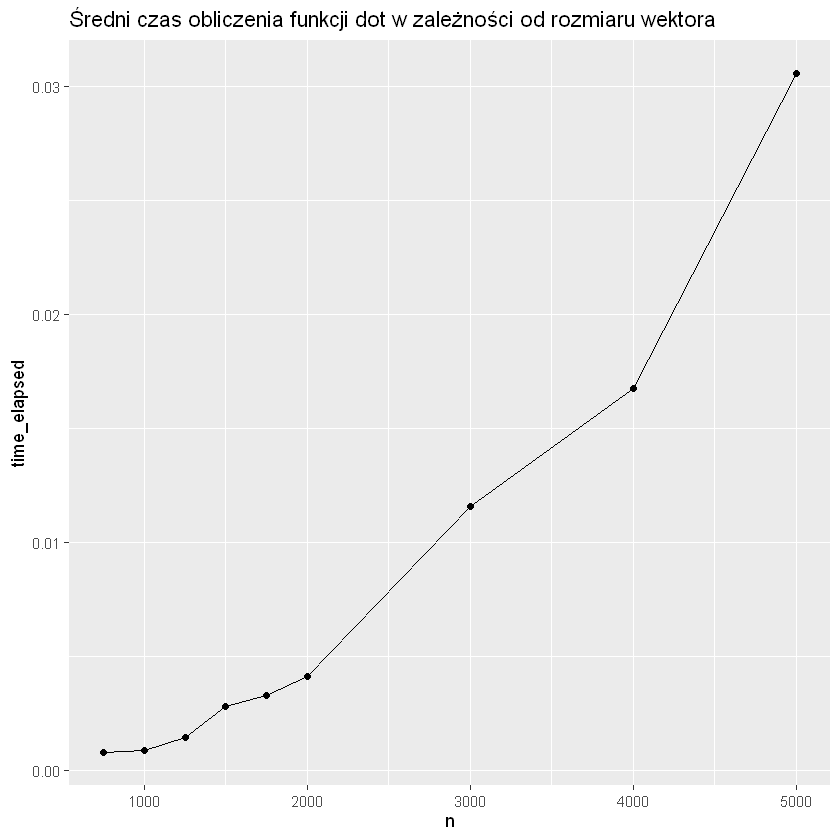

In [49]:
# Wykres średniego czasu obliczenia funkcji dot w zależności od rozmiaru wektora.
a <- ggplot(dot_data, aes(x=n, y=time_elapsed)) + geom_point() + geom_line() + ggtitle("Średni czas obliczenia funkcji dot w zależności od rozmiaru wektora")
# geom_point - rysuje punkty, geom_line - rysuje linię łączącą punkty
a

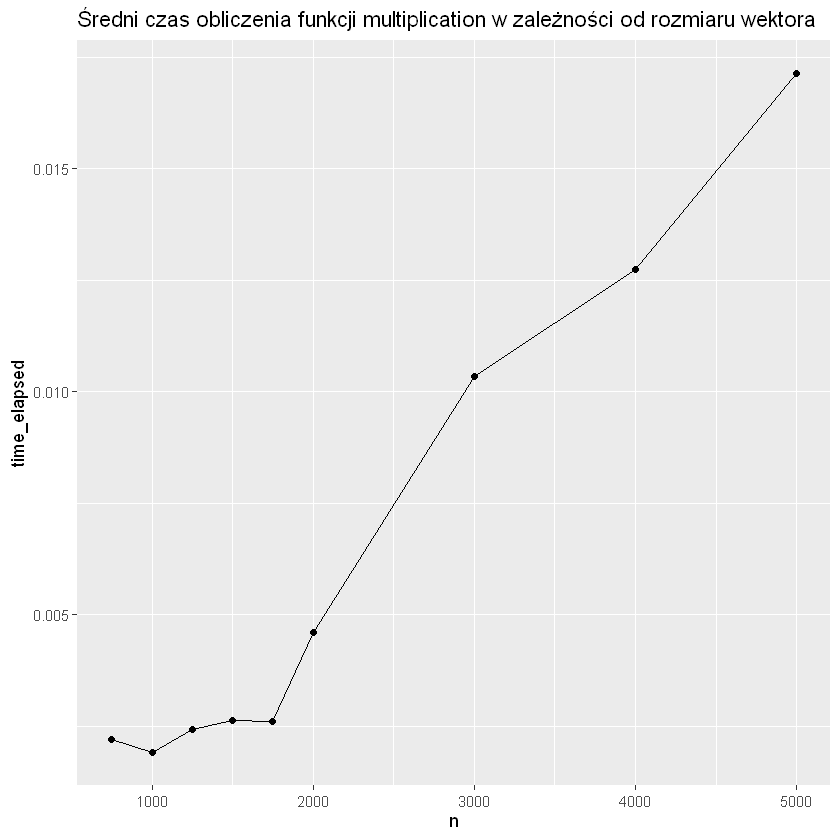

In [50]:
# Wykres średniego czasu obliczenia funkcji multiplication w zależności od rozmiaru wektora.
a <- ggplot(multiplication_data, aes(x=n, y=time_elapsed)) + geom_point() + geom_line() + ggtitle("Średni czas obliczenia funkcji multiplication w zależności od rozmiaru wektora")
# geom_point - rysuje punkty, geom_line - rysuje linię łączącą punkty
a

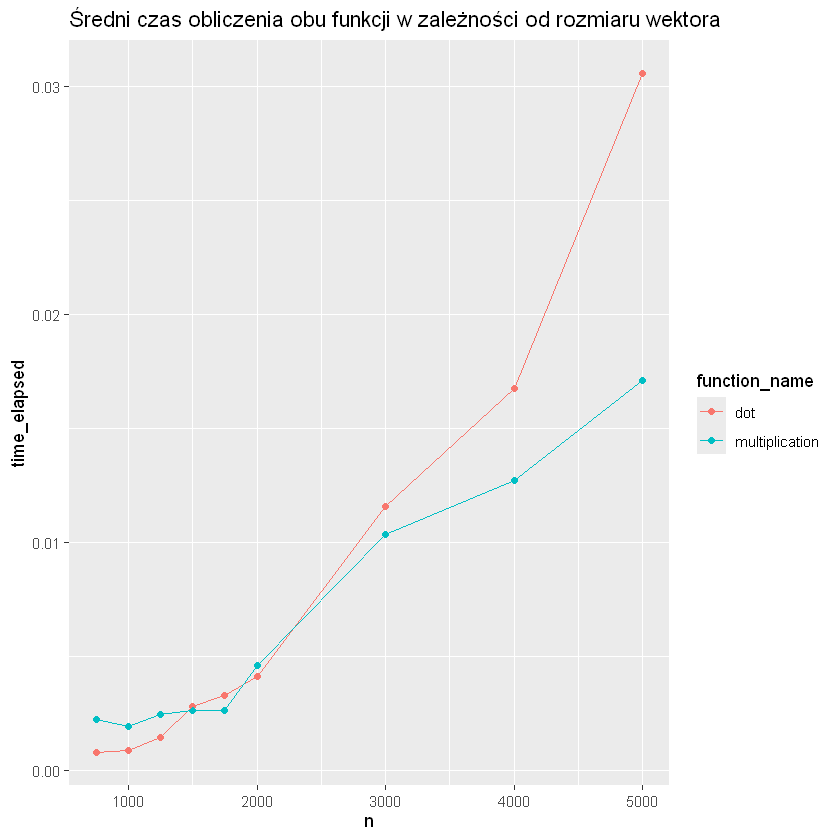

In [51]:
# Wykres średniego czasu obliczenia funkcji dot i multiplication w zależności od rozmiaru wektora.
a <- ggplot(avg_results, aes(x=n, y=time_elapsed, color=function_name)) + geom_point() + geom_line() + ggtitle("Średni czas obliczenia obu funkcji w zależności od rozmiaru wektora")
# geom_point - rysuje punkty, geom_line - rysuje linię łączącą punkty
a

In [ ]:
# Podpunkt 3. 
# Wykresy powinny zawierać informację o odchyleniu standardowym dla uzyskanych wyników (słupki błędów) .

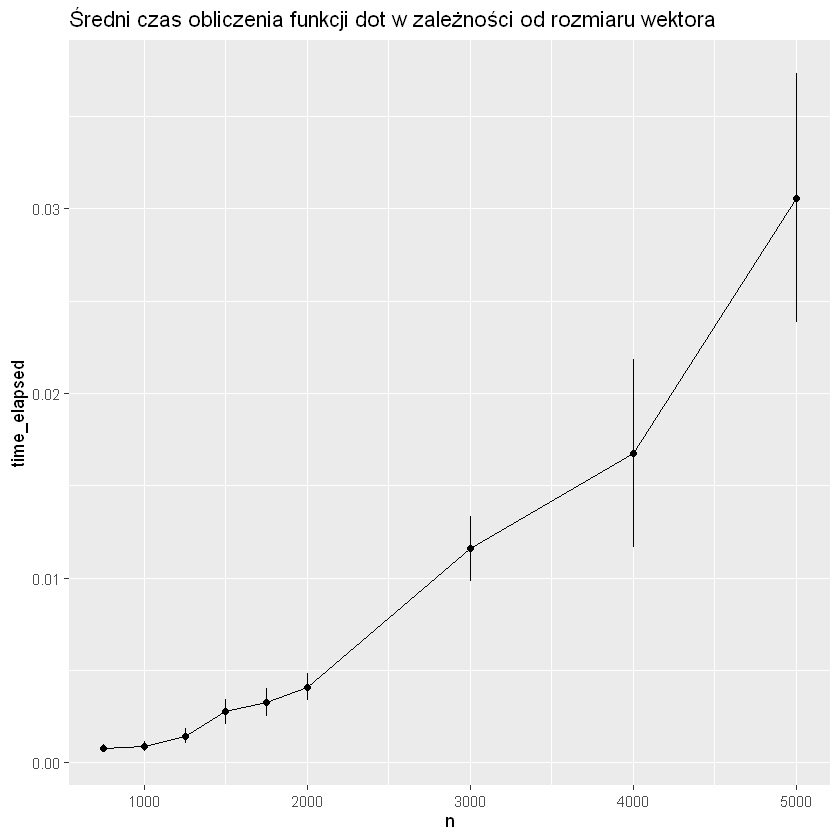

In [55]:
# Wykres dot z słupkami błędów
ggplot(dot_data, aes(x=n, y=time_elapsed)) + geom_point() + geom_line() +
ggtitle("Średni czas obliczenia funkcji dot w zależności od rozmiaru wektora") +
geom_errorbar(aes(ymin = time_elapsed-sd, ymax = time_elapsed+sd, width=.25))

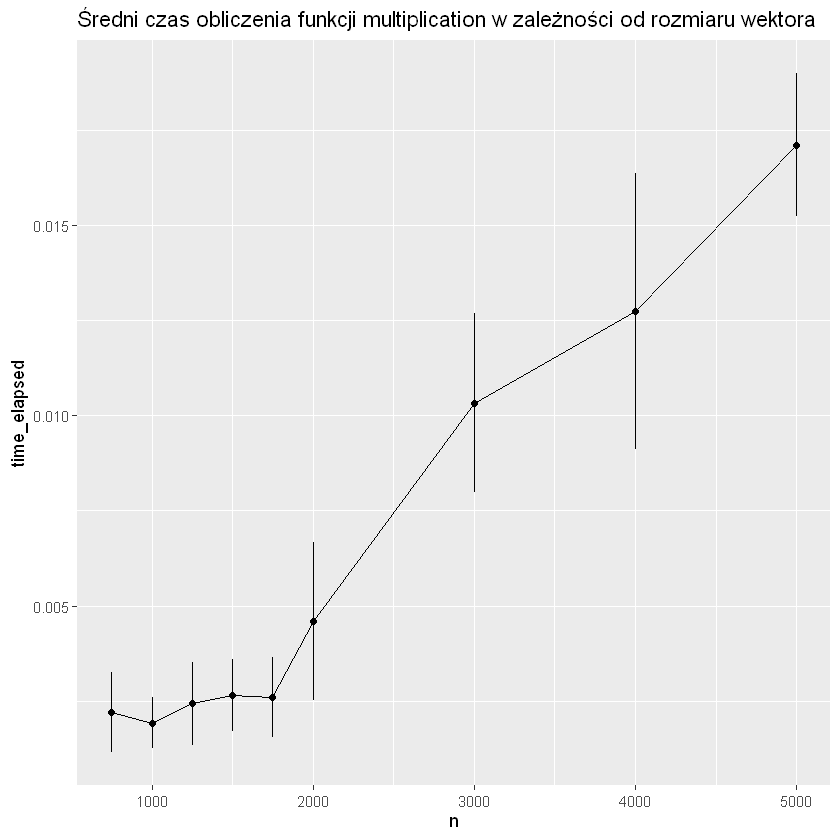

In [68]:
# Wykres multiplication z słupkami błędów
ggplot(multiplication_data, aes(x=n, y=time_elapsed)) + geom_point() + geom_line() +
ggtitle("Średni czas obliczenia funkcji multiplication w zależności od rozmiaru wektora") +
geom_errorbar(aes(ymin = time_elapsed-sd, ymax = time_elapsed+sd, width=0.25))

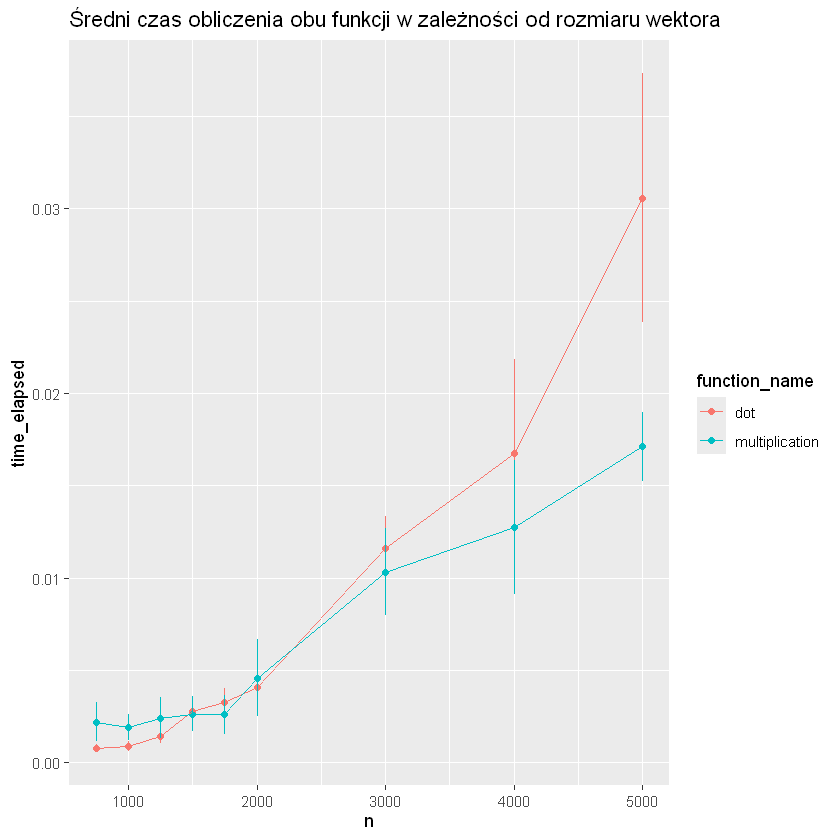

In [85]:
# Wykres obu funkcji z słupkami błedów
ggplot(avg_results, aes(x=n, y=time_elapsed, color=function_name)) + geom_point() + geom_line() +
ggtitle("Średni czas obliczenia obu funkcji w zależności od rozmiaru wektora") +
geom_errorbar(aes(ymin = time_elapsed-sd, ymax = time_elapsed+sd, width=0.25))